In [1]:
pip install numpy pandas matplotlib opencv-python scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

In [3]:
# Define paths and image configurations
DATADIR = r"C:\Users\aniru\Desktop\SCT_ML_3\dataset"  # Replace with your actual dataset folder path
CATEGORIES = ["cats", "dogs"]
IMG_SIZE = 128  # Resizing to 128x128 to keep computation light

data = []
labels = []

def create_data():
    for category in CATEGORIES:
        path = os.path.join(DATADIR, category)
        class_num = CATEGORIES.index(category)  # 0 for cats, 1 for dogs
        
        for img in os.listdir(path):
            try:
                # Read image in grayscale to simplify features for basic SVM
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                # Resize image
                resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                # Flatten the image matrix into a 1D vector ($64 \times 64 = 4096$ features)
                flattened_img = resized_array.flatten()
                
                data.append(flattened_img)
                labels.append(class_num)
            except Exception as e:
                pass

create_data()

# Convert lists to NumPy arrays and normalize pixel values (0-255 to 0-1)
X = np.array(data) / 255.0
y = np.array(labels)
print(f"Data loaded successfully. Features shape: {X.shape}, Labels shape: {y.shape}")

Data loaded successfully. Features shape: (1857, 16384), Labels shape: (1857,)


In [4]:
# Split data: 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 1485, Testing samples: 372


In [5]:
# Initialize the SVM Classifier
svm_model = SVC(kernel='linear', C=1.0)

print("Training the SVM model... (This might take a moment depending on dataset size)")
svm_model.fit(X_train, y_train)
print("Training complete!")

Training the SVM model... (This might take a moment depending on dataset size)
Training complete!


In [6]:
# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Print accuracy and classification report
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=CATEGORIES))

Model Accuracy: 52.15%

Classification Report:

              precision    recall  f1-score   support

        cats       0.48      0.54      0.51       171
        dogs       0.56      0.51      0.53       201

    accuracy                           0.52       372
   macro avg       0.52      0.52      0.52       372
weighted avg       0.53      0.52      0.52       372



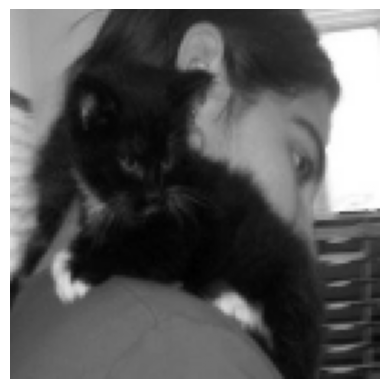

Actual Label   : cats
Predicted Label: dogs


In [7]:
# Pick a random sample from the test set
sample_index = 0  
plt.imshow(X_test[sample_index].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.axis('off')
plt.show()

actual_label = CATEGORIES[y_test[sample_index]]
predicted_label = CATEGORIES[y_pred[sample_index]]

print(f"Actual Label   : {actual_label}")
print(f"Predicted Label: {predicted_label}")